# Activation Functions in Deep Learning

This notebook covers the most important activation functions used in neural networks.

## Sigmoid Function

Maps any real number into (0, 1).

**Formula:** $\sigma(x) = \frac{1}{1 + e^{-x}}$

**Properties & Derivatives:**
- Domain: $(-\infty, +\infty)$
- Range: $(0, 1)$
- Monotonic increasing & Differentiable
- Derivative: $\sigma'(x) = \sigma(x)[1 - \sigma(x)]$
- Applications: Binary Classification, Output Layer
- Asymptotes: As $x \to \infty$, $\sigma(x) \to 1$; As $x \to -\infty$, $\sigma(x) \to 0$

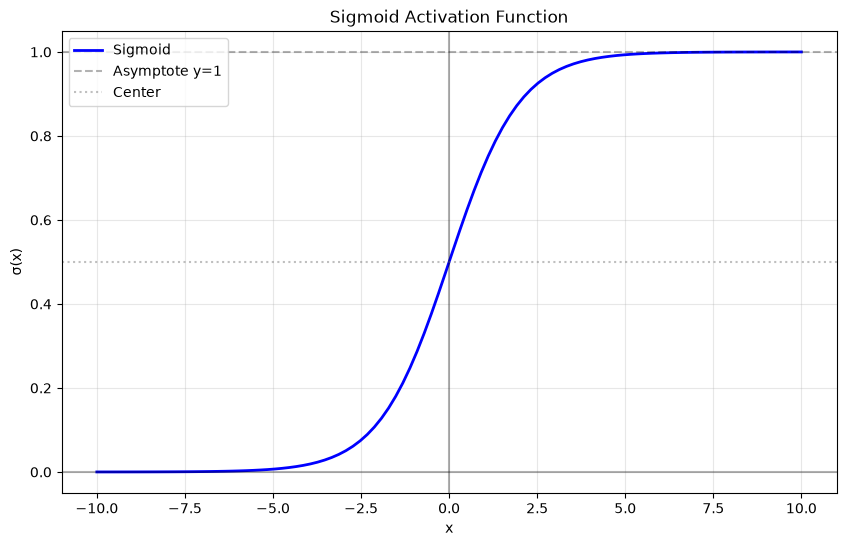

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Plot
x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Sigmoid')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='k', linestyle='--', alpha=0.3, label='Asymptote y=1')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Center')
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('σ(x)')
plt.title('Sigmoid Activation Function')
plt.legend()
plt.show()


## ReLU (Rectified Linear Unit)

Most widely used hidden-layer activation function.

**Formula:** $f(x) = \max(0, x)$

**Properties & Advantages:**
- Piecewise linear function
- Derivative: 0 for $x < 0$, 1 for $x > 0$
- Highly efficient computation & sparse activation
- Fast convergence in SGD
- Applications: CNNs, MLPs, Transformers

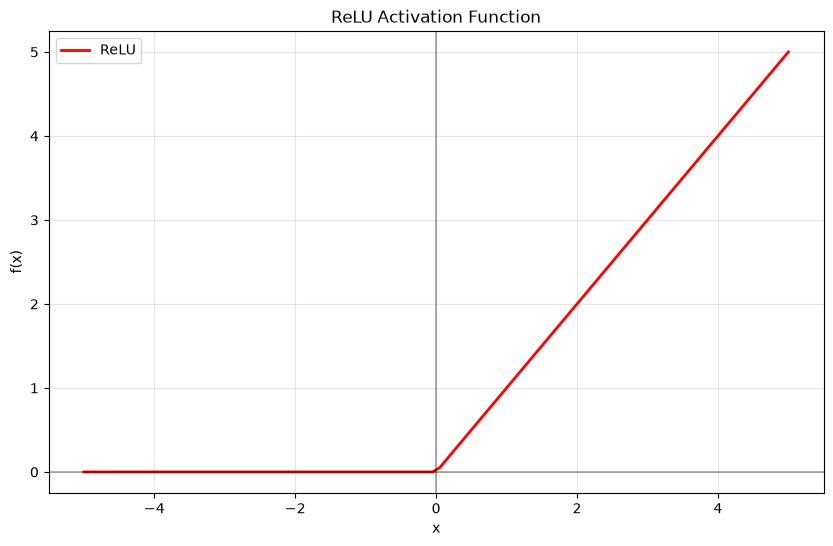

In [3]:
# ReLU function
def relu(x):
    return np.maximum(0, x)

# Plot
x = np.linspace(-5, 5, 100)
y = relu(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'r-', linewidth=2, label='ReLU')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('ReLU Activation Function')
plt.legend()
plt.show()


## Leaky ReLU

Improves ReLU by allowing a small negative slope for $x < 0$.

**Formula:** $f(x) = \max(\alpha x, x)$, where $\alpha \approx 0.01$

**Properties & Advantages:**
- Negative values survive with small slope $\alpha$
- Prevents "Dying ReLU" problem entirely
- Stable gradient flow during backprop
- Computationally efficient
- Better overall gradient distribution

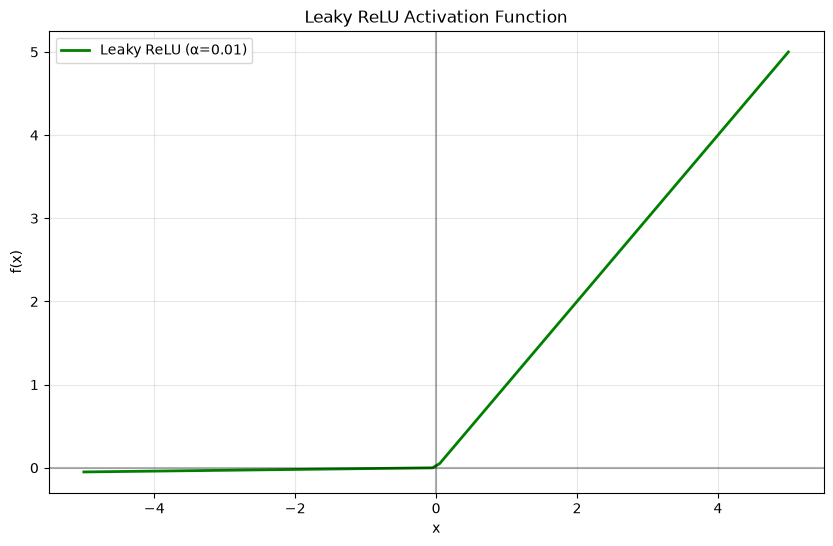

In [4]:
# Leaky ReLU function
def leaky_relu(x, alpha=0.01):
    return np.where(x >= 0, x, alpha * x)

# Plot
x = np.linspace(-5, 5, 100)
y = leaky_relu(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'g-', linewidth=2, label='Leaky ReLU (α=0.01)')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Leaky ReLU Activation Function')
plt.legend()
plt.show()


## Softmax Function

Converts unnormalized raw logits into a probability distribution.

**Formula:** $\sigma(z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$

**Properties & Applications:**
- Output probabilities sum exactly to 1.0
- Fully differentiable for multi-class cross-entropy loss
- Applications: Multi-class Classification
- Attention Mechanisms in Transformers
- Final layer in Large Language Models (LLMs)

Input Logits: [2.  1.  1.  2.  0.3]
Exponentiation: [7.3890561  2.71828183 2.71828183 7.3890561  1.34985881]
Probabilities: [0.34264853 0.12605335 0.12605335 0.34264853 0.06259624]
Sum of probabilities: 1.0


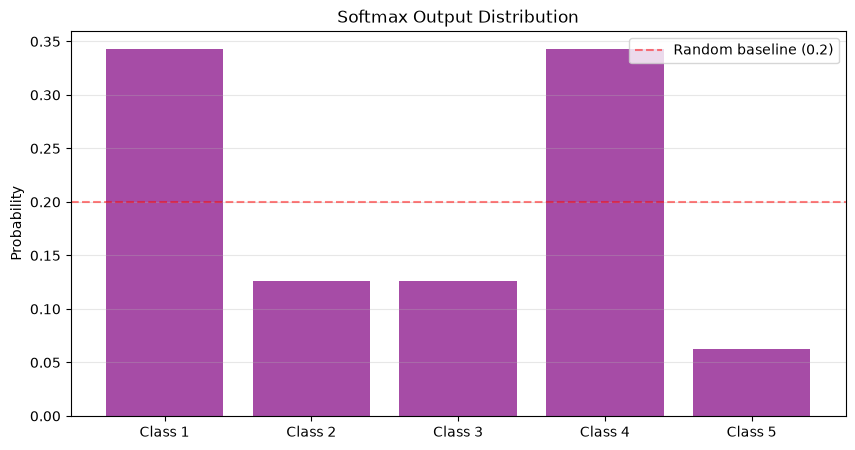

In [5]:
# Softmax function
def softmax(x):
    exp_x = np.exp(x - np.max(x))  # for numerical stability
    return exp_x / exp_x.sum()

# Example
logits = np.array([2.0, 1.0, 1.0, 2.0, 0.3])
probs = softmax(logits)

print("Input Logits:", logits)
print("Exponentiation:", np.exp(logits))
print("Probabilities:", probs)
print("Sum of probabilities:", probs.sum())

# Visualization
plt.figure(figsize=(10, 5))
categories = ['Class 1', 'Class 2', 'Class 3', 'Class 4', 'Class 5']
plt.bar(categories, probs, color='purple', alpha=0.7)
plt.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='Random baseline (0.2)')
plt.ylabel('Probability')
plt.title('Softmax Output Distribution')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()


## Comparison: All Activation Functions

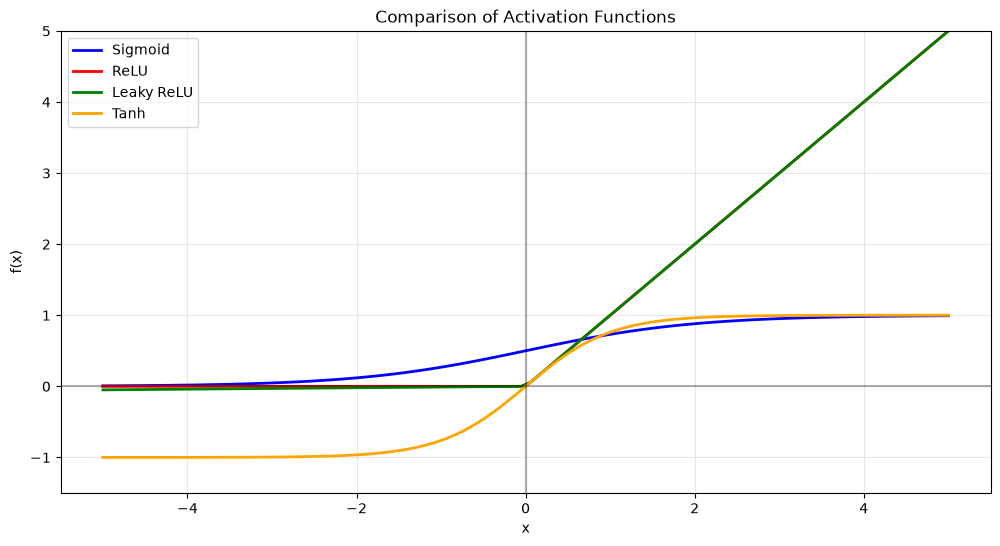

In [6]:
# Compare all activation functions
x = np.linspace(-5, 5, 100)

plt.figure(figsize=(12, 6))
plt.plot(x, sigmoid(x), 'b-', linewidth=2, label='Sigmoid')
plt.plot(x, relu(x), 'r-', linewidth=2, label='ReLU')
plt.plot(x, leaky_relu(x), 'g-', linewidth=2, label='Leaky ReLU')
plt.plot(x, np.tanh(x), 'orange', linewidth=2, label='Tanh')

plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Comparison of Activation Functions')
plt.legend()
plt.ylim(-1.5, 5)
plt.show()


## Key Points

### Advantages
1. Mitigates vanishing gradients
2. Computationally efficient
3. Sparse activation
4. Faster convergence
5. Excellent for deep networks

### Disadvantages
1. Dying ReLU problem
2. Zero gradient for $x < 0$
3. Not zero-centered
4. Unbounded positive output

### Dying ReLU
If input remains negative, output=0 and gradient=0.  
Neuron may stop learning permanently.